In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

def quantize(signal: np.array, bit_width):
    '''Q1.bit_width format'''
    frac_bits = bit_width - 1
    hi = (1 << frac_bits) - 1
    lo = -(1 << frac_bits)
    
    quantized = np.round(signal * (2**frac_bits))
    
    quantized = np.where(quantized > hi, hi, quantized)
    quantized = np.where(quantized < lo, lo, quantized)
    
    return quantized

def reverse_quantize(quant_signal, bit_width):
    frac_bits = bit_width - 1
    
    hi = (1 << frac_bits) - 1
    lo = -(1 << frac_bits)
    
    quant_signal = np.where(quant_signal > hi, hi, quant_signal)
    quant_signal = np.where(quant_signal < lo, lo, quant_signal)
    
    signal = quant_signal / (2**frac_bits)
    
    return signal
    

def two_comp_wrap(data: int, width: int):
    mask = (1 << width) - 1
    
    #remove top bits above width
    data &= mask
    #checking to see if num has wrapped above limit
    if(data >= 2**(width - 1)):
        data -= 2**(width)
        
    return data

In [2]:
def CIC(data: np.array, in_bit: int, out_bit: int, N: int, R: int, M: int = 1, shift: bool = True):
    '''Important Notes:
            -Parameters: 
                -N is the number of integrator and comb stages
                -R is the decimation ratio (aka. pick every R sample)
                -M remains unused currently (may be implemented)
            -Function has a slow_clk and clk, clk repersents system clock (MHz range),
            slow_clk repersents downsampled clock.
            -...recu variables refer to recursive elements in the filter. I.e. y[n-1], x[n-1]
            for intgrator and comb respectively
            -Added redudant variables for readability and symmetry, I.e. comb_module_out. These could be removed
            for efficiency
            -Shift parameter added to toggle the bitshift due to high gain. Likely need to rethink this
            -STILL TESTING
    '''
    
    '''-------Useful Constants------'''
    signal_len = data.size
    output_signal_len = int(np.ceil(signal_len / R))
    
    B_growth = int(np.ceil(N * np.log2(R * M)))
    gain = (R*M)**N
    
    '''----Register Declerations----'''
    integrator_module_in = data
    
    integrator_in = np.zeros(N, dtype = np.int64) 
    integrator_out = np.zeros(N, dtype = np.int64)
    integrator_out_recu = np.zeros(N, dtype = np.int64)
    
    integrator_module_out = 0
    
    comb_module_in = 0
    
    comb_in = np.zeros(N, dtype = np.int64)
    comb_out = np.zeros(N, dtype = np.int64)
    comb_in_recu = np.zeros(N, dtype = np.int64)
    
    comb_module_out = 0
    
    clk_slow = 0
    
    output_signal = np.zeros(output_signal_len, dtype = np.int64)
    
    '''---------Main Loop--------'''
    for clk in range(signal_len):
        
        '''Integrator Module'''
        for i in range(N):
            if(i == 0):
                integrator_in[i] = integrator_module_in[clk]
            else:
                integrator_in[i] = integrator_out[i - 1]
    
            integrator_out[i] = integrator_in[i] + integrator_out_recu[i]
            integrator_out[i] = two_comp_wrap(integrator_out[i], out_bit)
            integrator_out_recu[i] = integrator_out[i]
        
        integrator_module_out = integrator_out[-1]
        
        '''Comb Module'''
        if(clk % R == 0):
            for i in range(N):
                if(i == 0):
                    comb_in[i] = integrator_module_out
                else:
                    comb_in[i] = comb_out[i - 1]
                
                comb_out[i] = comb_in[i] - comb_in_recu[i]
                comb_out[i] = two_comp_wrap(comb_out[i], out_bit)
                comb_in_recu[i] = comb_in[i]
                
            comb_module_out = comb_out[-1]
            
            if(shift):
                comb_module_out = comb_module_out >> B_growth
            
            output_signal[clk_slow] = comb_module_out
            clk_slow += 1
    
    '''End Function'''
    return output_signal

Text(0, 0.5, 'Amplitude')

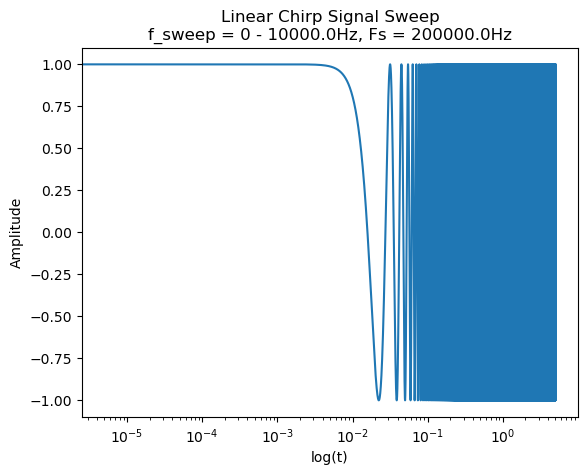

In [3]:
'''Testing'''

T = 5
fs = 200e3
t = np.linspace(0, T, int(fs * T))

f0 = 0
f1 = 10e3

linear_chirp = scipy.signal.chirp(t, f0, T, f1, method='linear')

plt.semilogx(t, linear_chirp)
plt.title(f"Linear Chirp Signal Sweep\nf_sweep = {f0} - {f1}Hz, Fs = {fs}Hz")
plt.xlabel("log(t)")
plt.ylabel("Amplitude")

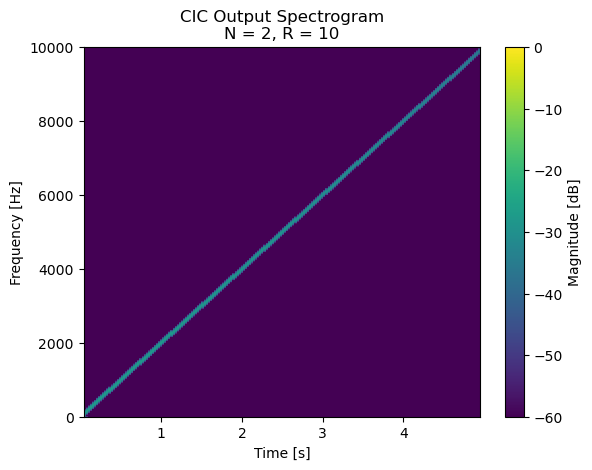

In [12]:
in_bit = 12
out_bit = 56
R = 10
N = 2

q_linear_chirp = quantize(linear_chirp, in_bit)

q_output_linear_chirp = CIC(data = q_linear_chirp, in_bit = in_bit, out_bit = out_bit, N = N, R = R)

output_linear_chirp = reverse_quantize(q_output_linear_chirp, in_bit)

fs_out = fs / R

f, t, Sxx = spectrogram(
    output_linear_chirp,
    fs=fs_out,
    window="hann",
    nperseg=2048,
    noverlap=1536,
    scaling="density",
    mode="magnitude"
)

Sxx_db = 20*np.log10(Sxx + 1e-12)

plt.figure()
plt.pcolormesh(t, f, Sxx_db, shading="auto", vmin=-60, vmax=0)
plt.ylim(0, fs_out/2)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title(f"CIC Output Spectrogram\nN = {N}, R = {R}")
plt.colorbar(label="Magnitude [dB]")
plt.show()

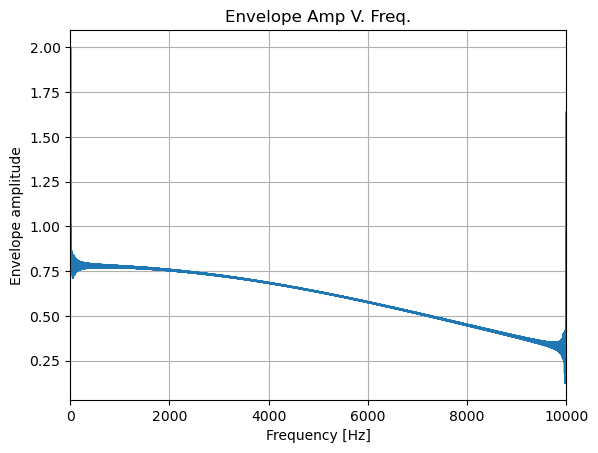

In [5]:
from scipy.signal import hilbert

fs_out = fs / R
t_out = np.arange(len(output_linear_chirp)) / fs_out

env = np.abs(hilbert(output_linear_chirp))

T = len(linear_chirp)/fs
f_inst = f0 + (f1-f0)*(t_out/T)

plt.plot(f_inst, env)
plt.xlim(0, fs_out/2)
plt.title("Envelope Amp V. Freq.")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Envelope amplitude")
plt.grid(True)
plt.show()

In [6]:
impulse_signal = np.zeros(100)
impulse_signal[0] = 1

print(impulse_signal)

N = 2
R = 2

out = CIC(data = impulse_signal, in_bit = in_bit, out_bit = out_bit, N = N, R = R, shift = False)

print(out)

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
